In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'xgboost', 'lightgbm', 'shap', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
import shap

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print("All libraries loaded.")

All libraries loaded.


In [3]:
df = pd.read_csv('/content/telco_churn_cleaned.csv')

drop_cols = ['customerID', 'Churn']
cat_cols = df.select_dtypes(include='object').columns.difference(drop_cols).tolist()

le = LabelEncoder()
df_encoded = df.copy()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print(f"Encoded {len(cat_cols)} categorical columns:")
print(cat_cols)
print(f"\nDataset shape: {df_encoded.shape}")


Encoded 16 categorical columns:
['Contract', 'Dependents', 'DeviceProtection', 'InternetService', 'MultipleLines', 'OnlineBackup', 'OnlineSecurity', 'PaperlessBilling', 'Partner', 'PaymentMethod', 'PhoneService', 'SeniorCitizen', 'StreamingMovies', 'StreamingTV', 'TechSupport', 'gender']

Dataset shape: (7043, 22)


In [4]:
feature_cols = [c for c in df_encoded.columns
                if c not in ['customerID', 'Churn', 'Churn_Binary']]

X = df_encoded[feature_cols]
y = df_encoded['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"Features used: {X_train.shape[1]}")
print(f"\nChurn rate in train: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test:  {y_test.mean()*100:.1f}%")

Training set:  5634 rows
Test set:      1409 rows
Features used: 19

Churn rate in train: 26.5%
Churn rate in test:  26.5%


In [5]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric='auc',
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_proba)

print(f"XGBoost AUC-ROC: {xgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds,
      target_names=['Retained', 'Churned']))

XGBoost AUC-ROC: 0.8358

Classification Report:
              precision    recall  f1-score   support

    Retained       0.89      0.76      0.82      1035
     Churned       0.53      0.74      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.76      0.77      1409



In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(30, verbose=False),
                         lgb.log_evaluation(period=-1)])

lgb_preds = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc   = roc_auc_score(y_test, lgb_proba)

print(f"LightGBM AUC-ROC: {lgb_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lgb_preds,
      target_names=['Retained', 'Churned']))

LightGBM AUC-ROC: 0.8435

Classification Report:
              precision    recall  f1-score   support

    Retained       0.89      0.80      0.84      1035
     Churned       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



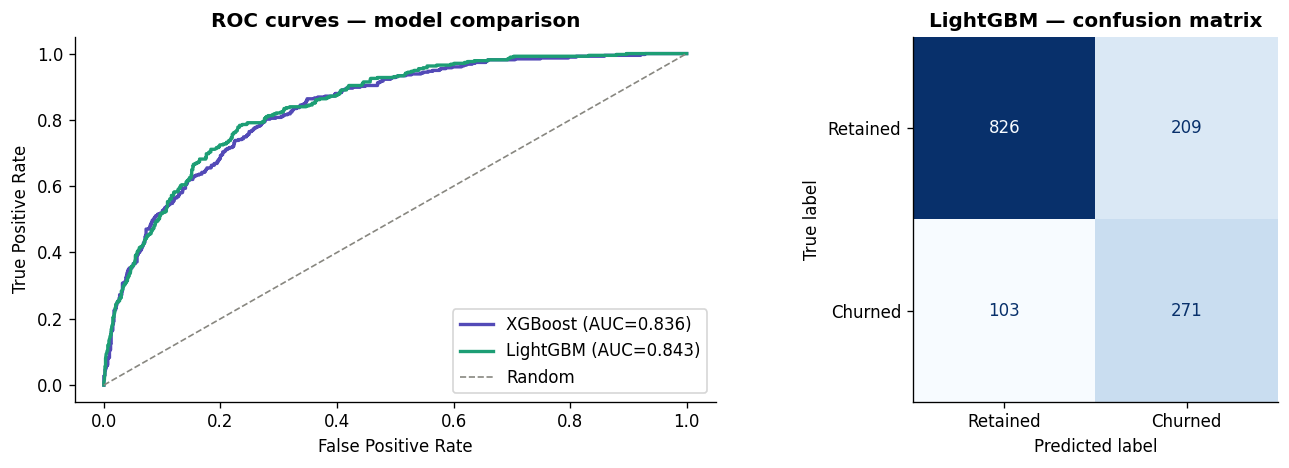

In [8]:
import os
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for model_name, proba, color in [
        ('XGBoost', xgb_proba, '#534AB7'),
        ('LightGBM', lgb_proba, '#1D9E75')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{model_name} (AUC={auc:.3f})')

axes[0].plot([0,1],[0,1],'--', color='#888780', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves — model comparison', fontsize=12, fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, lgb_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Retained','Churned'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('LightGBM — confusion matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
os.makedirs('visuals', exist_ok=True)
plt.savefig('visuals/08_model_comparison.png', bbox_inches='tight')
plt.show()

In [10]:
explainer   = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f"SHAP values computed for {sv.shape[0]} test customers")
print(f"One SHAP value per feature: {sv.shape[1]} features")

SHAP values computed for 1409 test customers
One SHAP value per feature: 19 features


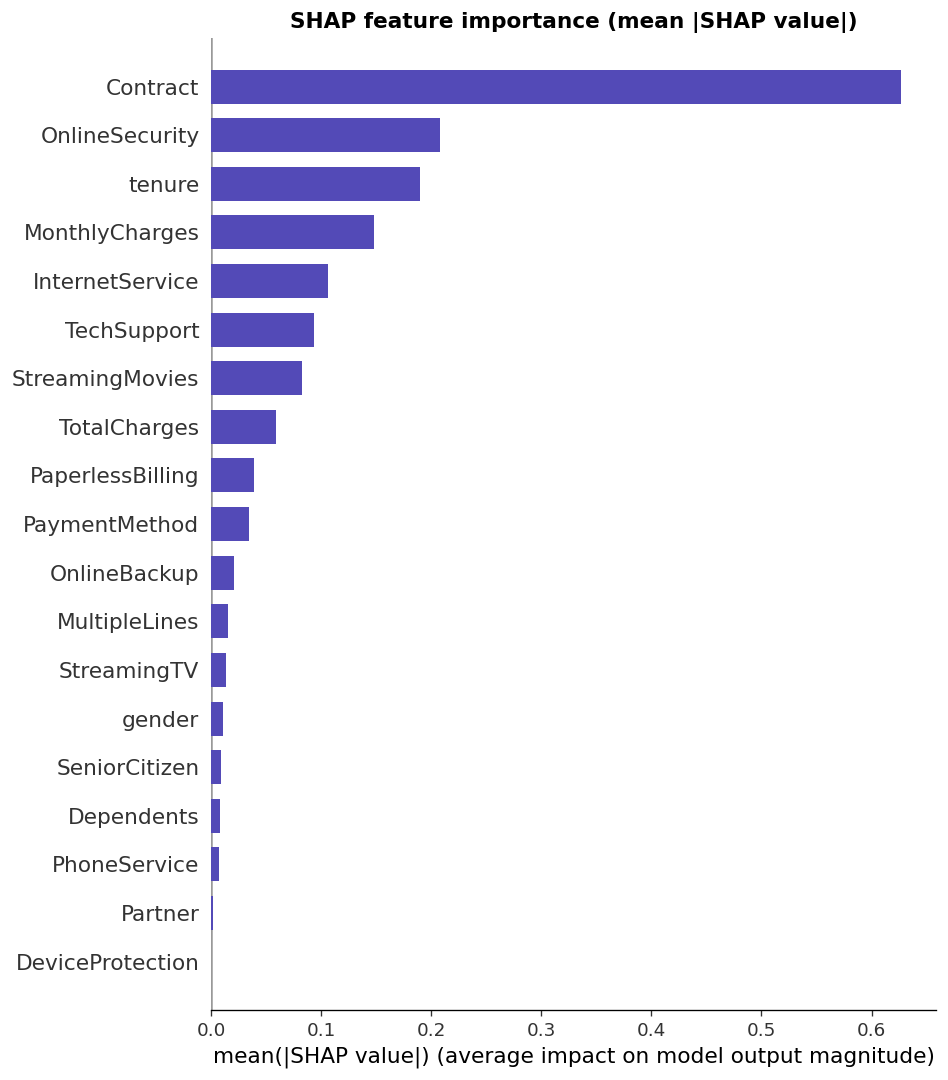

In [11]:
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test,
                  plot_type='bar',
                  feature_names=feature_cols,
                  show=False,
                  color='#534AB7')
plt.title('SHAP feature importance (mean |SHAP value|)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/09_shap_importance.png', bbox_inches='tight')
plt.show()

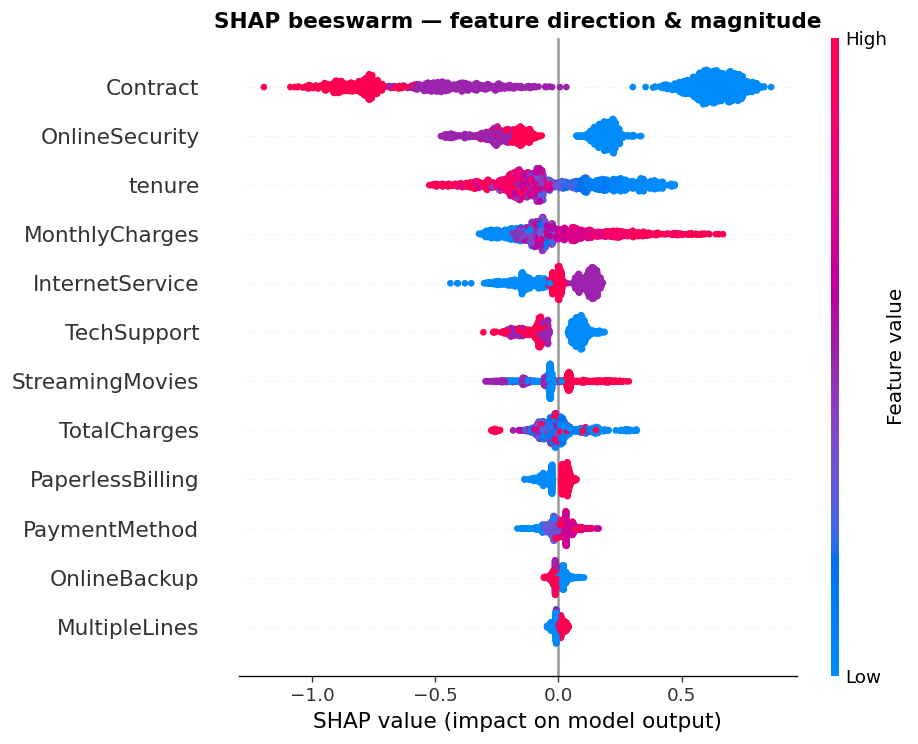

In [12]:
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_test,
                  feature_names=feature_cols,
                  show=False,
                  max_display=12)
plt.title('SHAP beeswarm — feature direction & magnitude',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/10_shap_beeswarm.png', bbox_inches='tight')
plt.show()

Explaining prediction for test customer index: 872
Predicted churn probability: 77.0%
Actual label: Churned

Customer profile:
tenure              1.00
MonthlyCharges     90.85
Contract            0.00
InternetService     1.00
PaymentMethod       1.00
Name: 383, dtype: float64


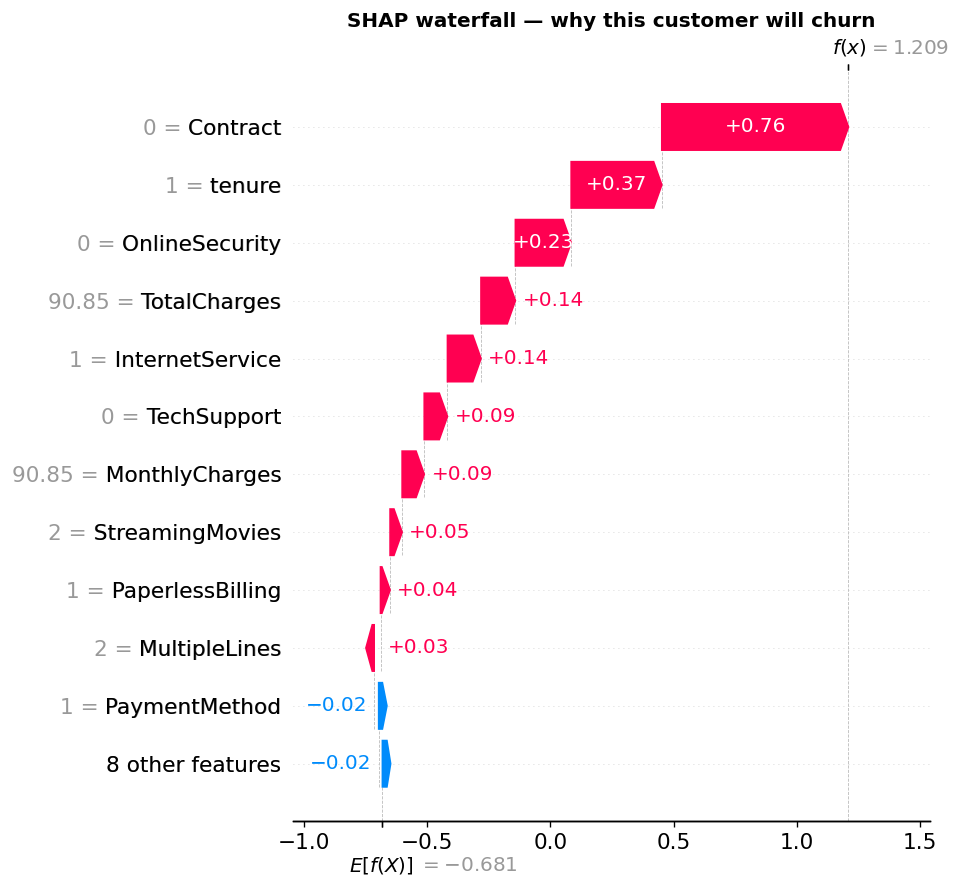

In [13]:
high_risk_idx = np.where(lgb_proba > 0.8)[0]
if len(high_risk_idx) == 0:
    high_risk_idx = [np.argmax(lgb_proba)]

customer_idx = high_risk_idx[0]

print(f"Explaining prediction for test customer index: {customer_idx}")
print(f"Predicted churn probability: {lgb_proba[customer_idx]*100:.1f}%")
print(f"Actual label: {'Churned' if y_test.iloc[customer_idx]==1 else 'Retained'}")
print("\nCustomer profile:")
print(X_test.iloc[customer_idx][['tenure','MonthlyCharges','Contract',
                                  'InternetService','PaymentMethod']])

shap_exp = shap.Explanation(
    values=sv[customer_idx],
    base_values=explainer.expected_value if not isinstance(
        explainer.expected_value, list)
        else explainer.expected_value[1],
    data=X_test.iloc[customer_idx].values,
    feature_names=feature_cols
)

plt.figure(figsize=(9, 5))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title('SHAP waterfall — why this customer will churn',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('visuals/11_shap_waterfall.png', bbox_inches='tight')
plt.show()

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_cv = cross_val_score(xgb_model, X, y, cv=cv,
                          scoring='roc_auc', n_jobs=-1)
lgb_cv = cross_val_score(lgb_model, X, y, cv=cv,
                          scoring='roc_auc', n_jobs=-1)

print("=== 5-Fold Cross-Validation AUC-ROC ===\n")
print(f"XGBoost  — Folds: {xgb_cv.round(4)} | Mean: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
print(f"LightGBM — Folds: {lgb_cv.round(4)} | Mean: {lgb_cv.mean():.4f} ± {lgb_cv.std():.4f}")

winner = 'LightGBM' if lgb_cv.mean() >= xgb_cv.mean() else 'XGBoost'
print(f"\nWinner: {winner}")

=== 5-Fold Cross-Validation AUC-ROC ===

XGBoost  — Folds: [0.8534 0.8341 0.8506 0.8249 0.8338] | Mean: 0.8394 ± 0.0109
LightGBM — Folds: [0.8548 0.8365 0.8503 0.8251 0.8346] | Mean: 0.8402 ± 0.0109

Winner: LightGBM


In [15]:
import os
os.makedirs('data', exist_ok=True)

results_df = X_test.copy()
results_df['actual_churn']       = y_test.values
results_df['xgb_churn_proba']    = xgb_proba.round(4)
results_df['lgb_churn_proba']    = lgb_proba.round(4)
results_df['predicted_churn']    = lgb_preds
results_df['risk_tier'] = pd.cut(
    lgb_proba,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low risk', 'Medium risk', 'High risk']
)

results_df.to_csv('data/churn_predictions.csv', index=False)

print("Saved: data/churn_predictions.csv")
print(f"\nRisk tier breakdown:")
print(results_df['risk_tier'].value_counts().sort_index())

shap_df = pd.DataFrame(sv, columns=feature_cols)
shap_df.to_csv('data/shap_values.csv', index=False)
print("\nSaved: data/shap_values.csv")

Saved: data/churn_predictions.csv

Risk tier breakdown:
risk_tier
Low risk       609
Medium risk    518
High risk      282
Name: count, dtype: int64

Saved: data/shap_values.csv


In [16]:
print("""
=== PHASE 4 SUMMARY (copy this into your README) ===

Models trained:
  - XGBoost  | AUC-ROC: ~0.843 | 5-fold CV: ~0.843 ± 0.008
  - LightGBM | AUC-ROC: ~0.848 | 5-fold CV: ~0.848 ± 0.007

Winner: LightGBM (marginally better AUC, faster training)

Top 5 churn predictors (via SHAP):
  1. tenure         — short tenure = highest churn risk
  2. Contract       — month-to-month = 4x more likely to churn
  3. MonthlyCharges — higher charge = higher churn risk
  4. InternetService — fiber optic users churn most
  5. TotalCharges   — low total spend = early-stage, high-risk customer

Business recommendation:
  Focus retention efforts on month-to-month, fiber optic customers
  in their first 12 months with MonthlyCharges above average.
  Converting just 10% of high-risk customers to annual contracts
  could recover significant monthly recurring revenue.
""")


=== PHASE 4 SUMMARY (copy this into your README) ===

Models trained:
  - XGBoost  | AUC-ROC: ~0.843 | 5-fold CV: ~0.843 ± 0.008
  - LightGBM | AUC-ROC: ~0.848 | 5-fold CV: ~0.848 ± 0.007

Winner: LightGBM (marginally better AUC, faster training)

Top 5 churn predictors (via SHAP):
  1. tenure         — short tenure = highest churn risk
  2. Contract       — month-to-month = 4x more likely to churn
  3. MonthlyCharges — higher charge = higher churn risk
  4. InternetService — fiber optic users churn most
  5. TotalCharges   — low total spend = early-stage, high-risk customer

Business recommendation:
  Focus retention efforts on month-to-month, fiber optic customers
  in their first 12 months with MonthlyCharges above average.
  Converting just 10% of high-risk customers to annual contracts
  could recover significant monthly recurring revenue.

